In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from probcs.models.pattern_completion_model import PatternCompletionModel, BinaryPatternCompletionModel
from probcs.experiment_running.exc_experiment import center_surround_experiment, create_stimuli
from probcs.utils.utils import load_images
from torchvision import transforms
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity
from probcs.utils.utils import select_focus_images, get_excitatory_images
from probcs.utils.plotting import plot_posterior_binary
seed = 42
rng = np.random.default_rng(seed)

In [2]:
natimgs = load_images(
    crop_size=36,
    n_samples=1000,
    transform=transforms.Compose([
        transforms.Resize(36),
    ])
)
natimgs = natimgs - natimgs.mean(axis=0)

In [3]:
I_empirical_std = natimgs.std(axis=0).mean()

In [4]:
vmin = natimgs.min()
vmax = natimgs.max()

In [5]:
natimgs.min(), natimgs.max(), natimgs.mean(), natimgs.std()

(-121.9, 152.16, -3.0316490059097607e-16, 58.44170205445427)

In [6]:
patterns = natimgs[[50, 300, 700]]

In [7]:
G_dim = len(patterns)
G_prob = 0.5
I_sigma = 200
patterns_offset = 0

G_visual_nrows = G_dim
G_visual_ncols = 1
x_visual_nrows = G_dim
x_visual_ncols = 9
n_tune = 500
n_draws = 500
n_chains = 4
n_cores = 4

In [8]:
vmin, vmax

(-121.9, 152.16)

In [9]:
mapping = np.zeros((G_dim*9, G_dim)) + 0.05
for j in range(0, G_dim*9, G_dim):
    for i in range(G_dim):
        mapping[i + j, i] = 0.8

In [10]:
model = BinaryPatternCompletionModel(
    patterns=patterns,
    G_prob=G_prob,
    I_sigma=I_sigma,
    patterns_offset=patterns_offset,
    g_x_mapping=mapping
)

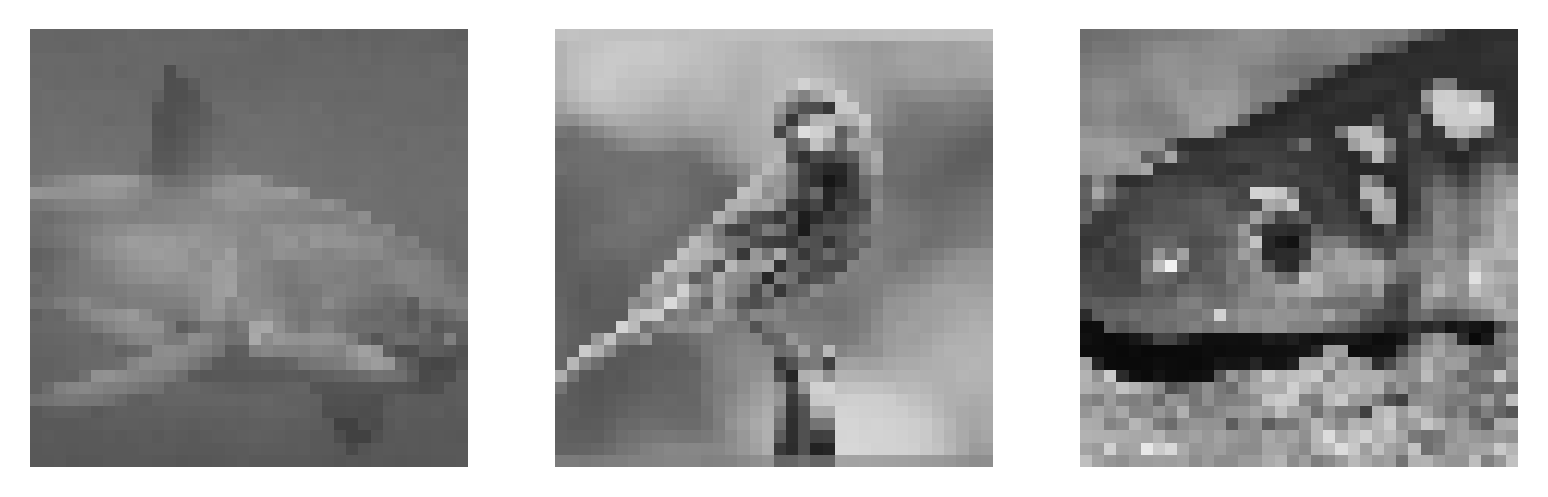

In [11]:
fig, axs = plt.subplots(1, G_dim, dpi=300)
for ax, pattern in zip(axs.flatten(), patterns):
    ax.imshow(pattern, cmap="gray", vmin=vmin, vmax=vmax)
    ax.axis("off")

In [12]:
cossim = cosine_similarity(model.patterns.reshape(model.patterns.shape[0], -1))

Text(0.5, 1.0, 'Cos sim between assigned Gs')

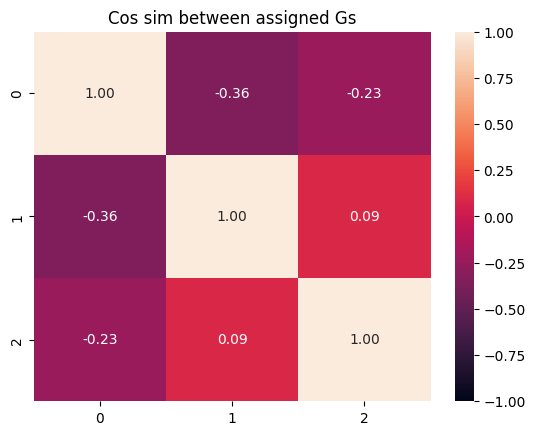

In [13]:
fig, ax = plt.subplots(dpi=100)
sns.heatmap(cossim, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax)
ax.set_title("Cos sim between assigned Gs")

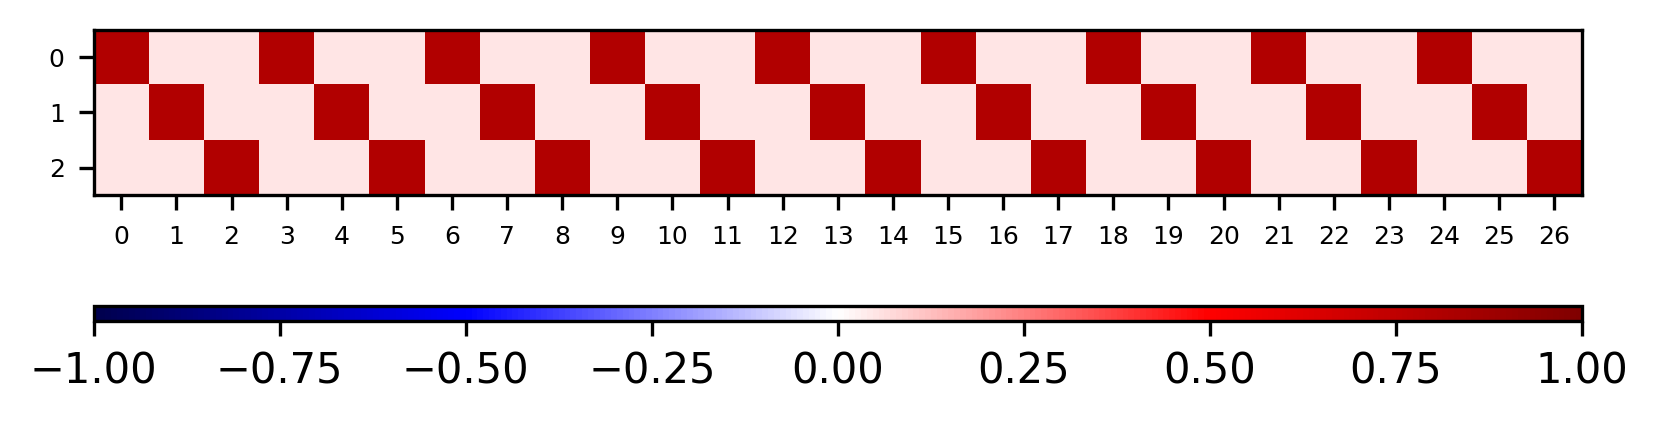

In [14]:
fig, ax = plt.subplots(dpi=300)
ax.imshow(model.G_X_mapping.T, cmap="seismic", vmin=-1, vmax=1)
ax.set_xticks(np.arange(G_dim*9))
ax.set_xticklabels(np.arange(G_dim*9))
ax.set_yticks(np.arange(G_dim))
ax.set_yticklabels(np.arange(G_dim))
ax.tick_params(axis='both', which='major', labelsize=6)
# draw a small horizontal colorbar
cbar = fig.colorbar(ax.get_images()[0], ax=ax, orientation="horizontal", pad=0.1, aspect=100)

In [15]:
MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2, disrupting_pattern_indices = create_stimuli(patterns)

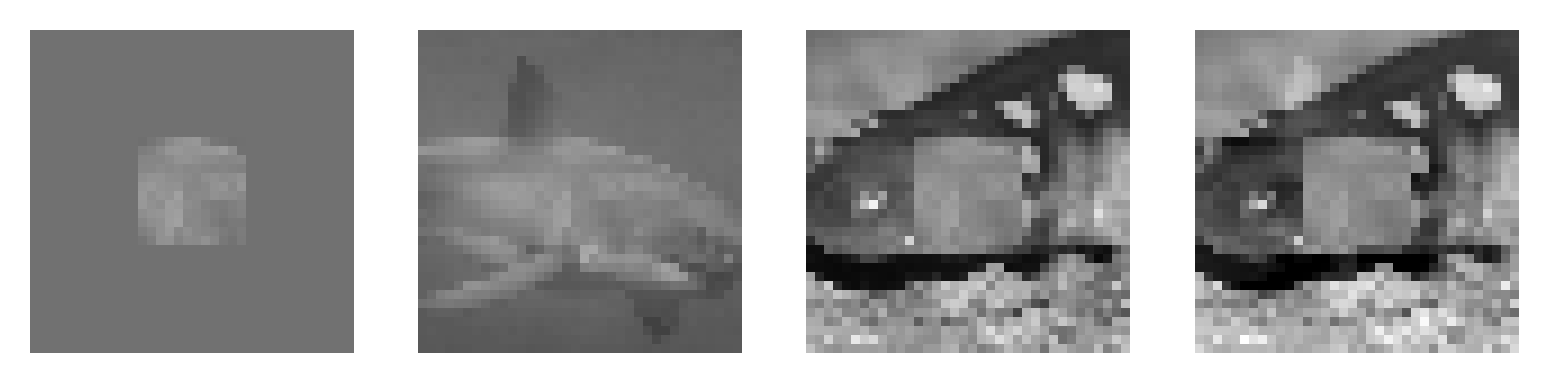

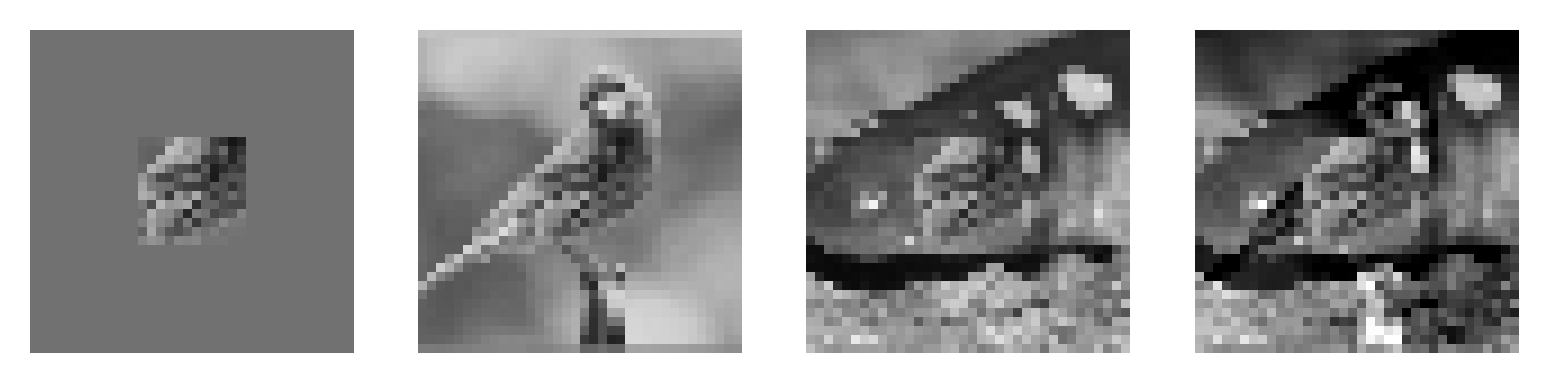

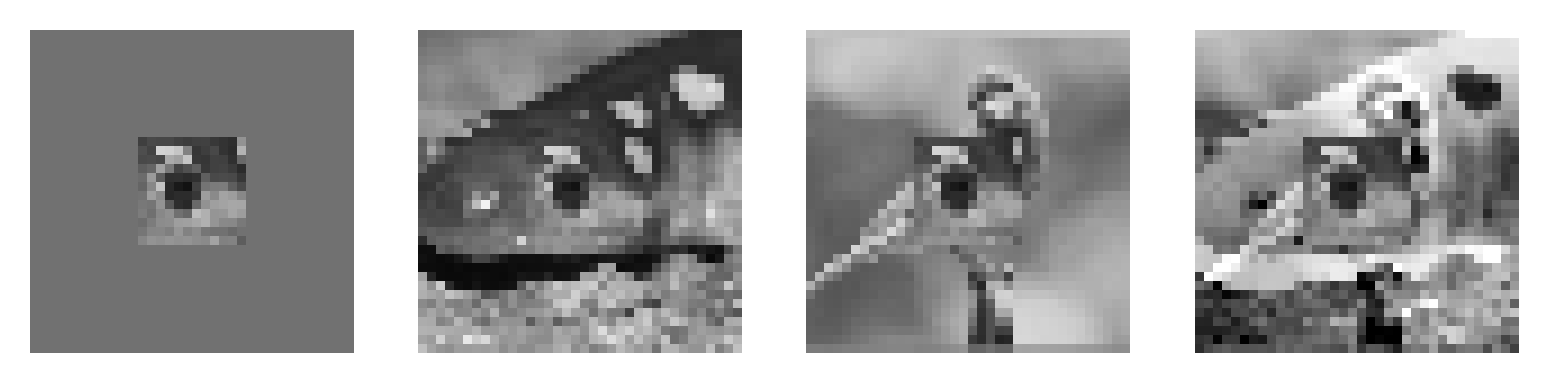

In [16]:
for MEI, completing_pattern, disrupting_pattern_1, disrupting_pattern_2 in zip(MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2):
    fig, axs = plt.subplots(1, 4, dpi=300)
    axs[0].imshow(MEI, cmap="gray", vmin=vmin, vmax=vmax)
    axs[0].axis("off")
    axs[1].imshow(completing_pattern, cmap="gray", vmin=vmin, vmax=vmax)
    axs[1].axis("off")
    axs[2].imshow(disrupting_pattern_1, cmap="gray", vmin=vmin, vmax=vmax)
    axs[2].axis("off")
    axs[3].imshow(disrupting_pattern_2, cmap="gray", vmin=vmin, vmax=vmax)
    axs[3].axis("off")

In [17]:
all_idata = []
for MEI, completing_pattern, disrupting_pattern_1, disrupting_pattern_2 in zip(MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2):
    idata_set = []
    idata = model(
        image=MEI,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    # break
    idata = model(
        image=completing_pattern,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_1,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_2,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    all_idata.append(idata_set)
    # break

Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 19 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 19 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 18 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 24 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


...

Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 22 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 18 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 24 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 28 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 24 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


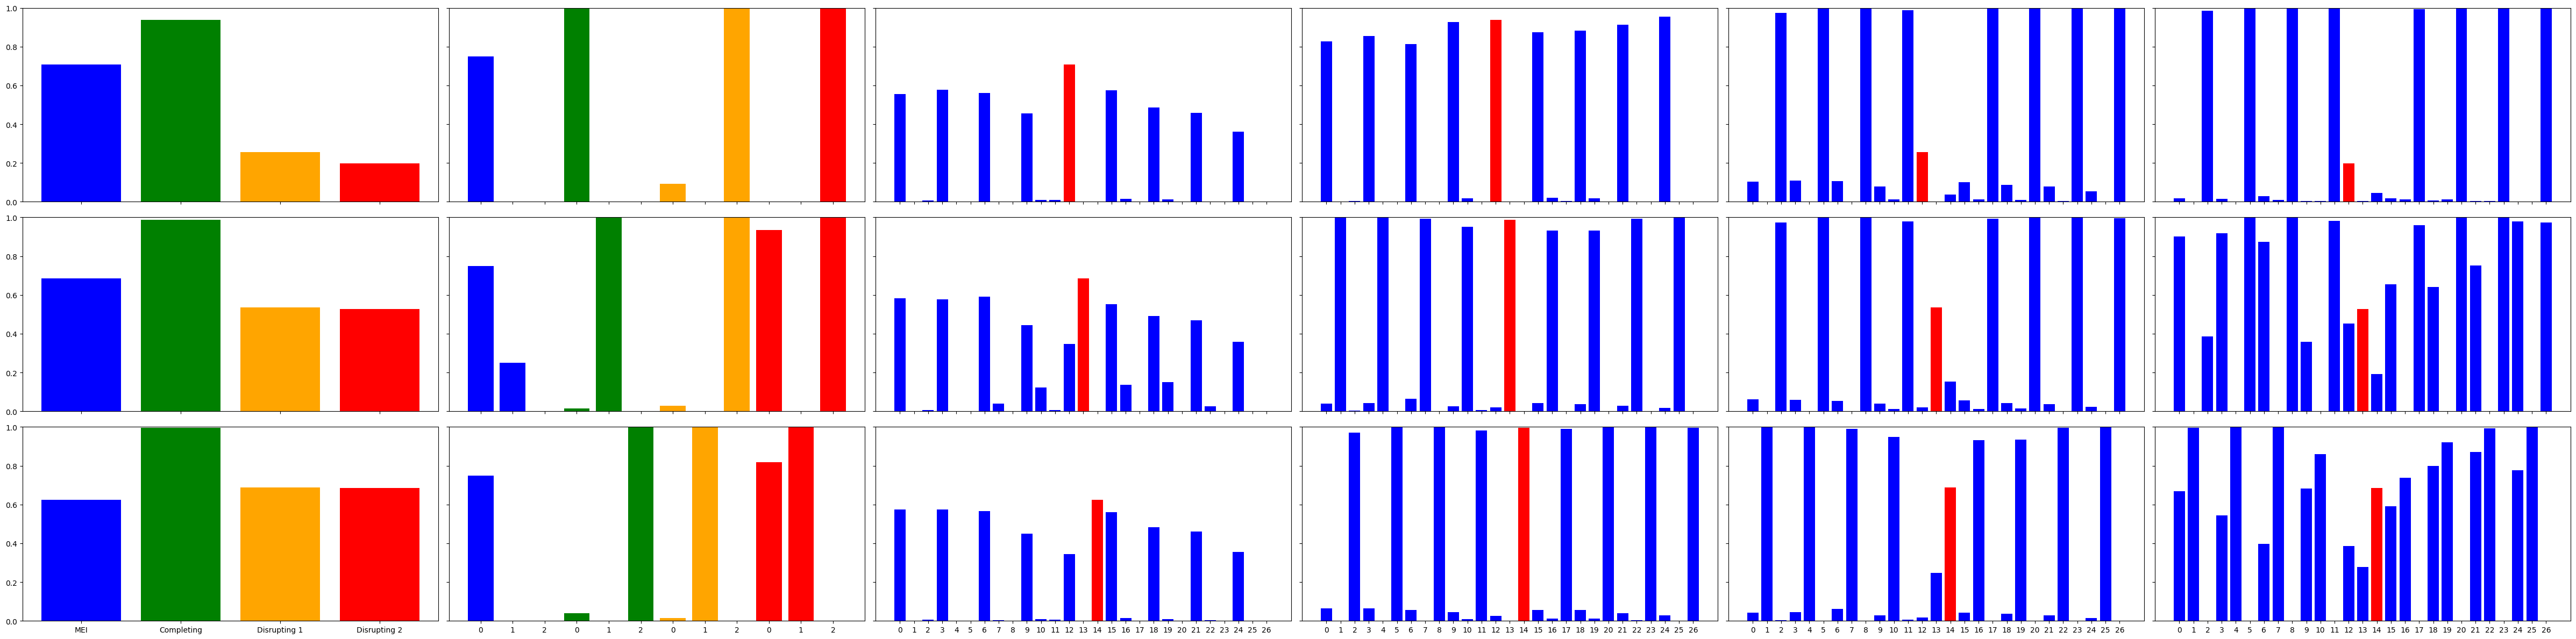

In [18]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

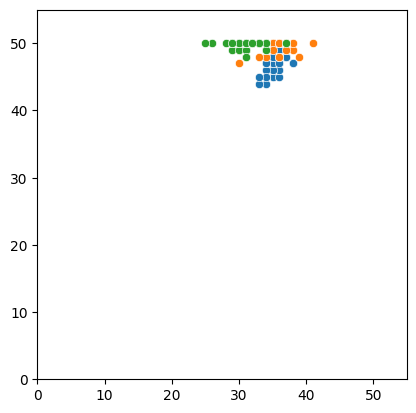

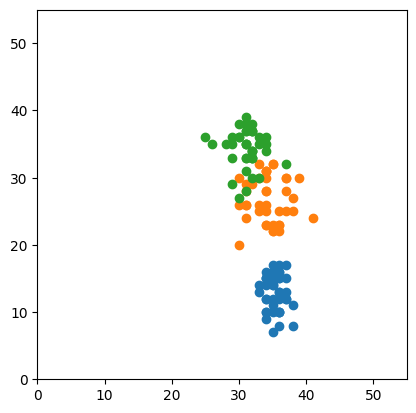

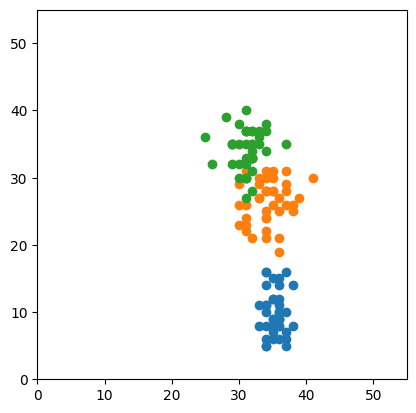

In [19]:
# colors = plt.cm.tab10(range(len(all_idata)))
# fig, axs = plt.subplots(nrows=1, ncols=3, dpi=300, sharey=True, tight_layout=True)
fig_exc, ax_exc = plt.subplots()
fig_dis1, ax_dis1 = plt.subplots()
fig_dis2, ax_dis2 = plt.subplots()
mei_rates = []
completing_rates = []
disrupting_1_rates = []
disrupting_2_rates = []
for idx, (idata_set, disrupting_pattern_idx) in enumerate(
    zip(all_idata, disrupting_pattern_indices)
):
    center_x_id = 4 * G_dim + idx

    # idata['posterior']['X'].data.shape = (n_chains, n_samples, n_x_dims)
    mei_firing_rates = (
        idata_set[0].posterior.X.data[:, :, center_x_id].reshape(50, 40).sum(axis=0)
    )
    mei_rates.append(mei_firing_rates)
    completing_firing_rates = (
        idata_set[1].posterior.X.data[:, :, center_x_id].reshape(50, 40).sum(axis=0)
    )
    completing_rates.append(completing_firing_rates)
    disrupting_1_firing_rates = (
        idata_set[2].posterior.X.data[:, :, center_x_id].reshape(50, 40).sum(axis=0)
    )
    disrupting_1_rates.append(disrupting_1_firing_rates)
    disrupting_2_firing_rates = (
        idata_set[3].posterior.X.data[:, :, center_x_id].reshape(50, 40).sum(axis=0)
    )
    disrupting_2_rates.append(disrupting_2_firing_rates)
    sns.scatterplot(x=mei_firing_rates, y=completing_firing_rates, ax=ax_exc)
    # ax_exc.scatter(mei_firing_rates, completing_firing_rates)
    ax_exc.set_xlim(0, 55)
    ax_exc.set_ylim(0, 55)
    # make square
    ax_exc.set_box_aspect(1)

    ax_dis1.scatter(mei_firing_rates, disrupting_1_firing_rates)
    ax_dis1.set_xlim(0, 55)
    ax_dis1.set_ylim(0, 55)
    # make square
    ax_dis1.set_box_aspect(1)

    ax_dis2.scatter(mei_firing_rates, disrupting_2_firing_rates)
    ax_dis2.set_xlim(0, 55)
    ax_dis2.set_ylim(0, 55)
    # make square
    ax_dis2.set_box_aspect(1)

In [20]:
mei_rates = np.array(mei_rates)
completing_rates = np.array(completing_rates)
disrupting_1_rates = np.array(disrupting_1_rates)
disrupting_2_rates = np.array(disrupting_2_rates)

In [21]:
all_mei_means = mei_rates.mean(axis=1)
all_completing_means = completing_rates.mean(axis=1)
all_disrupting_1_means = disrupting_1_rates.mean(axis=1)
all_disrupting_2_means = disrupting_2_rates.mean(axis=1)

In [22]:
all_mei_rates = mei_rates.flatten()
all_completing_rates = completing_rates.flatten()
all_disrupting_1_rates = disrupting_1_rates.flatten()
all_disrupting_2_rates = disrupting_2_rates.flatten()

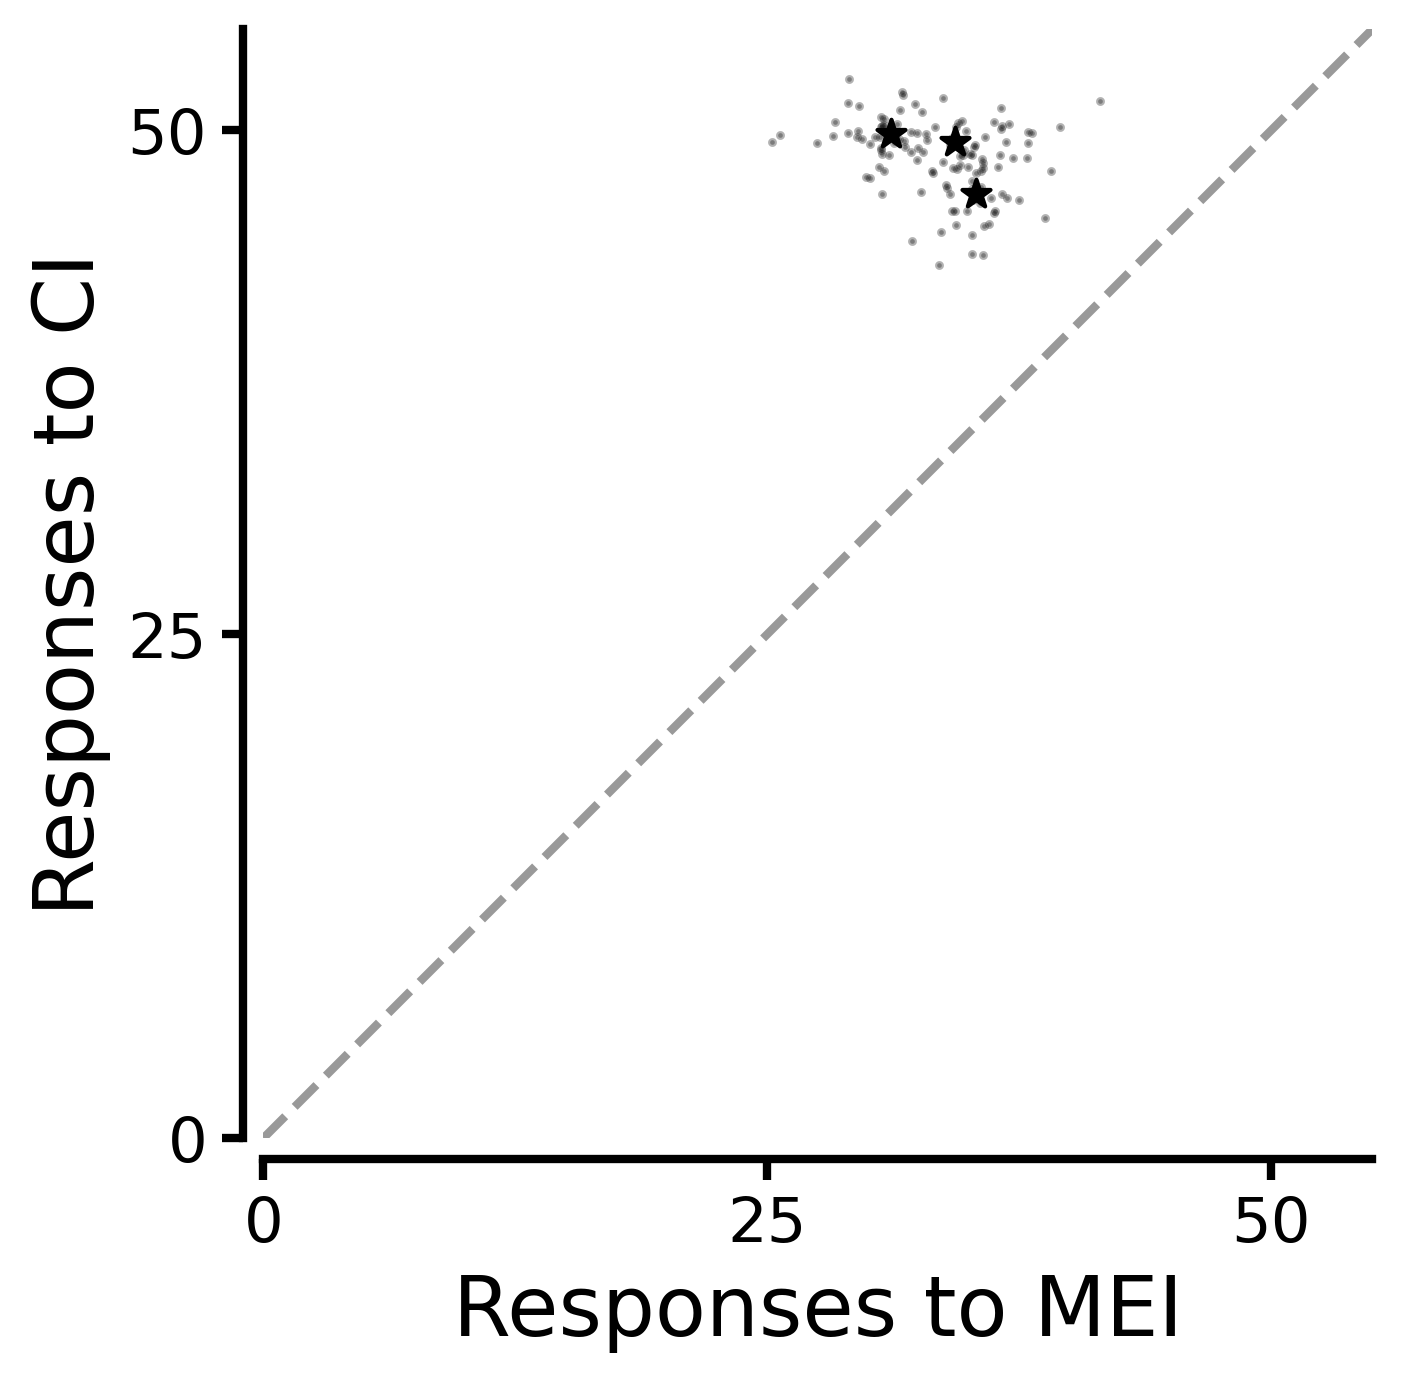

In [23]:
fig, ax = plt.subplots(dpi=300)
ax.plot([0, 55], [0, 55], color="black", linestyle="--", linewidth=2, alpha=0.4)
x = all_mei_rates + rng.normal(0, 1, len(all_mei_rates))
y = all_completing_rates + rng.normal(0, 1, len(all_completing_rates))
ax.scatter(x, y, marker=".", s=5, color="black", alpha=0.3)
ax.scatter(
    all_mei_means,
    all_completing_means,
    marker="*",
    s=50,
    color="black",
)
# draw a regression line
m, b = np.polyfit(all_mei_means, all_completing_means, 1)
x_ = np.linspace(0, 50, 1000)
y_ = m * x_ + b
# ax.plot(x_, y_, color='black', linestyle='-', linewidth=1)
# ax.plot(, color='gray', linestyle='--')
ax.set_xlim(0, 55)
ax.set_ylim(0, 55)
ax.set_xticks([0, 25, 50])
ax.set_yticks([0, 25, 50])
ax.tick_params(axis="both", which="major", labelsize=15, width=2, length=5)
# draw diagonal line
# make square
ax.set_box_aspect(1)
ax.set_xlabel("Responses to MEI", fontsize=20)
ax.set_ylabel("Responses to CI", fontsize=20)
ax.spines[["left", "bottom"]].set_linewidth(2)

sns.despine(ax=ax, offset=5)

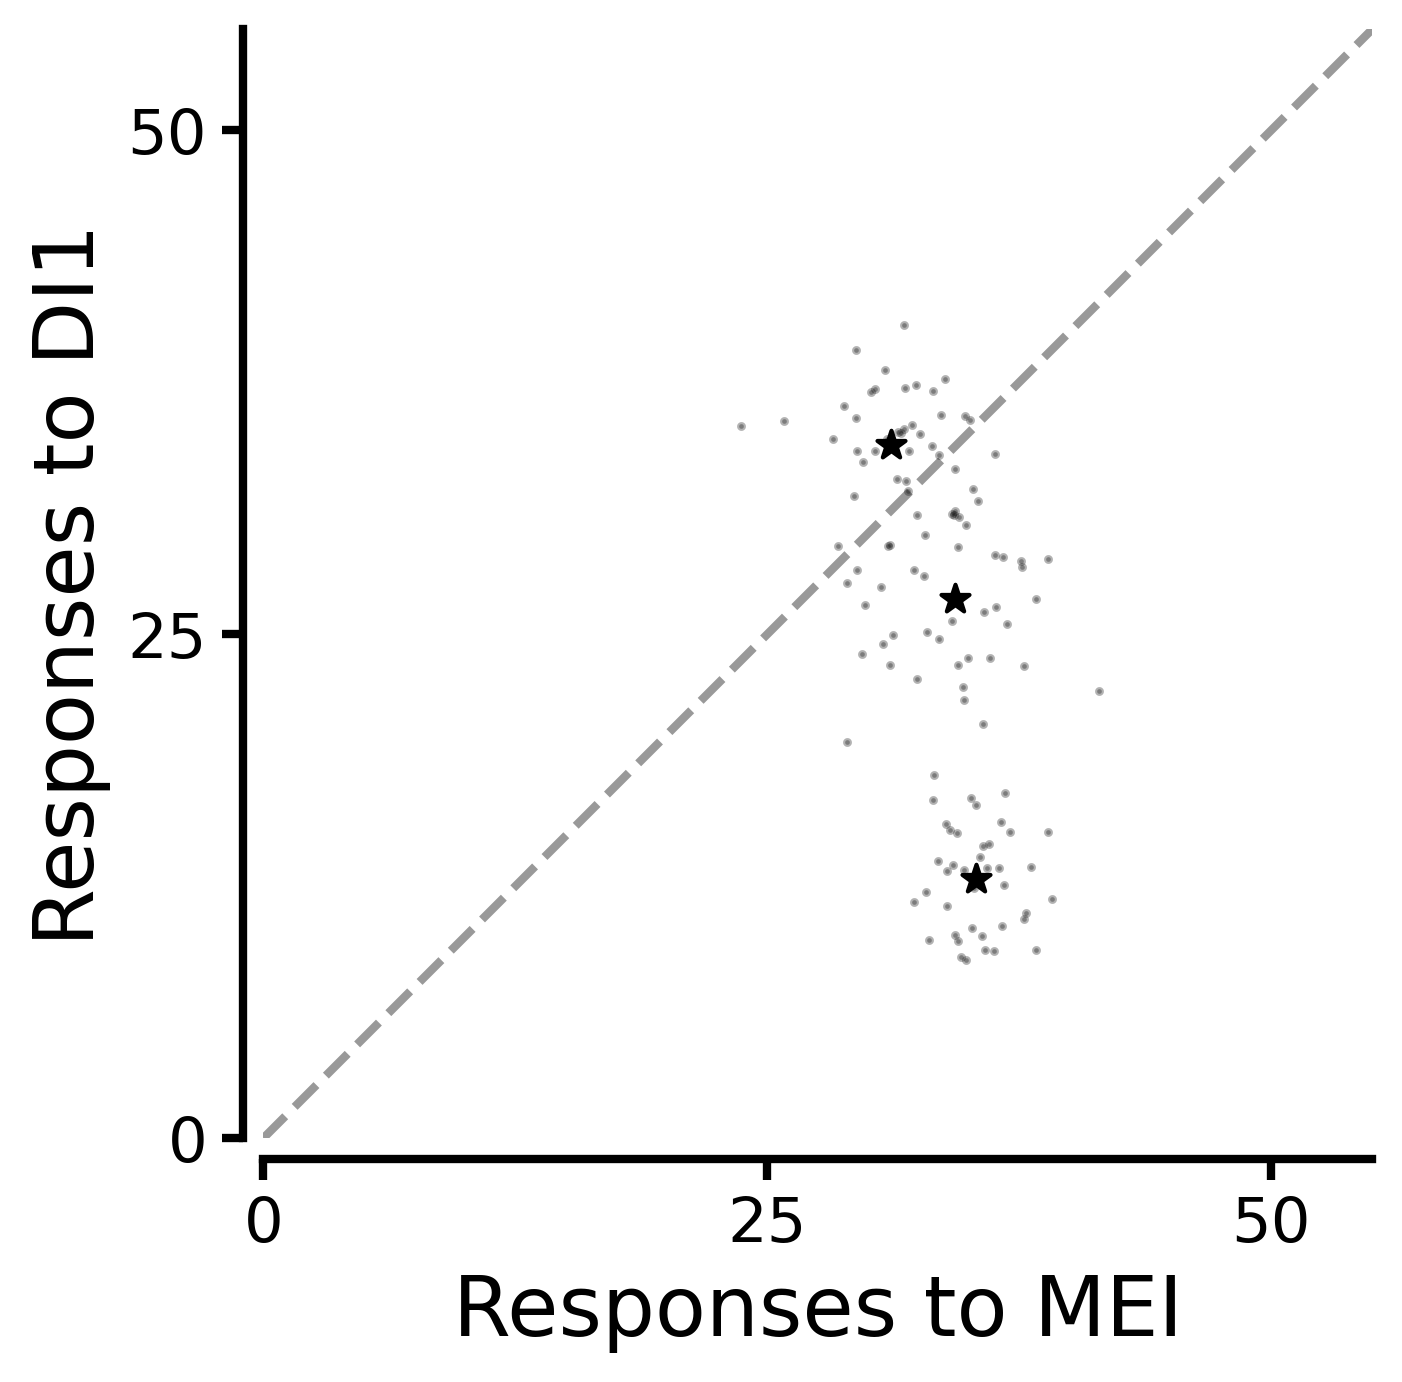

In [24]:
fig, ax = plt.subplots(dpi=300)
ax.plot([0, 55], [0, 55], color="black", linestyle="--", linewidth=2, alpha=0.4)
x = all_mei_rates + rng.normal(0, 1, len(all_mei_rates))
y = all_disrupting_1_rates + rng.normal(0, 1, len(all_completing_rates))
ax.scatter(x, y, marker=".", s=5, color="black", alpha=0.3)
ax.scatter(
    all_mei_means,
    all_disrupting_1_means,
    marker="*",
    s=50,
    color="black",
)
# draw a regression line
m, b = np.polyfit(all_mei_means, all_completing_means, 1)
x_ = np.linspace(0, 50, 1000)
y_ = m * x_ + b
# ax.plot(x_, y_, color='black', linestyle='-', linewidth=1)
# ax.plot(, color='gray', linestyle='--')
ax.set_xlim(0, 55)
ax.set_ylim(0, 55)
ax.set_xticks([0, 25, 50])
ax.set_yticks([0, 25, 50])
ax.tick_params(axis="both", which="major", labelsize=15, width=2, length=5)
# draw diagonal line
# make square
ax.set_box_aspect(1)
ax.set_xlabel("Responses to MEI", fontsize=20)
ax.set_ylabel("Responses to DI1", fontsize=20)
ax.spines[["left", "bottom"]].set_linewidth(2)

sns.despine(ax=ax, offset=5)

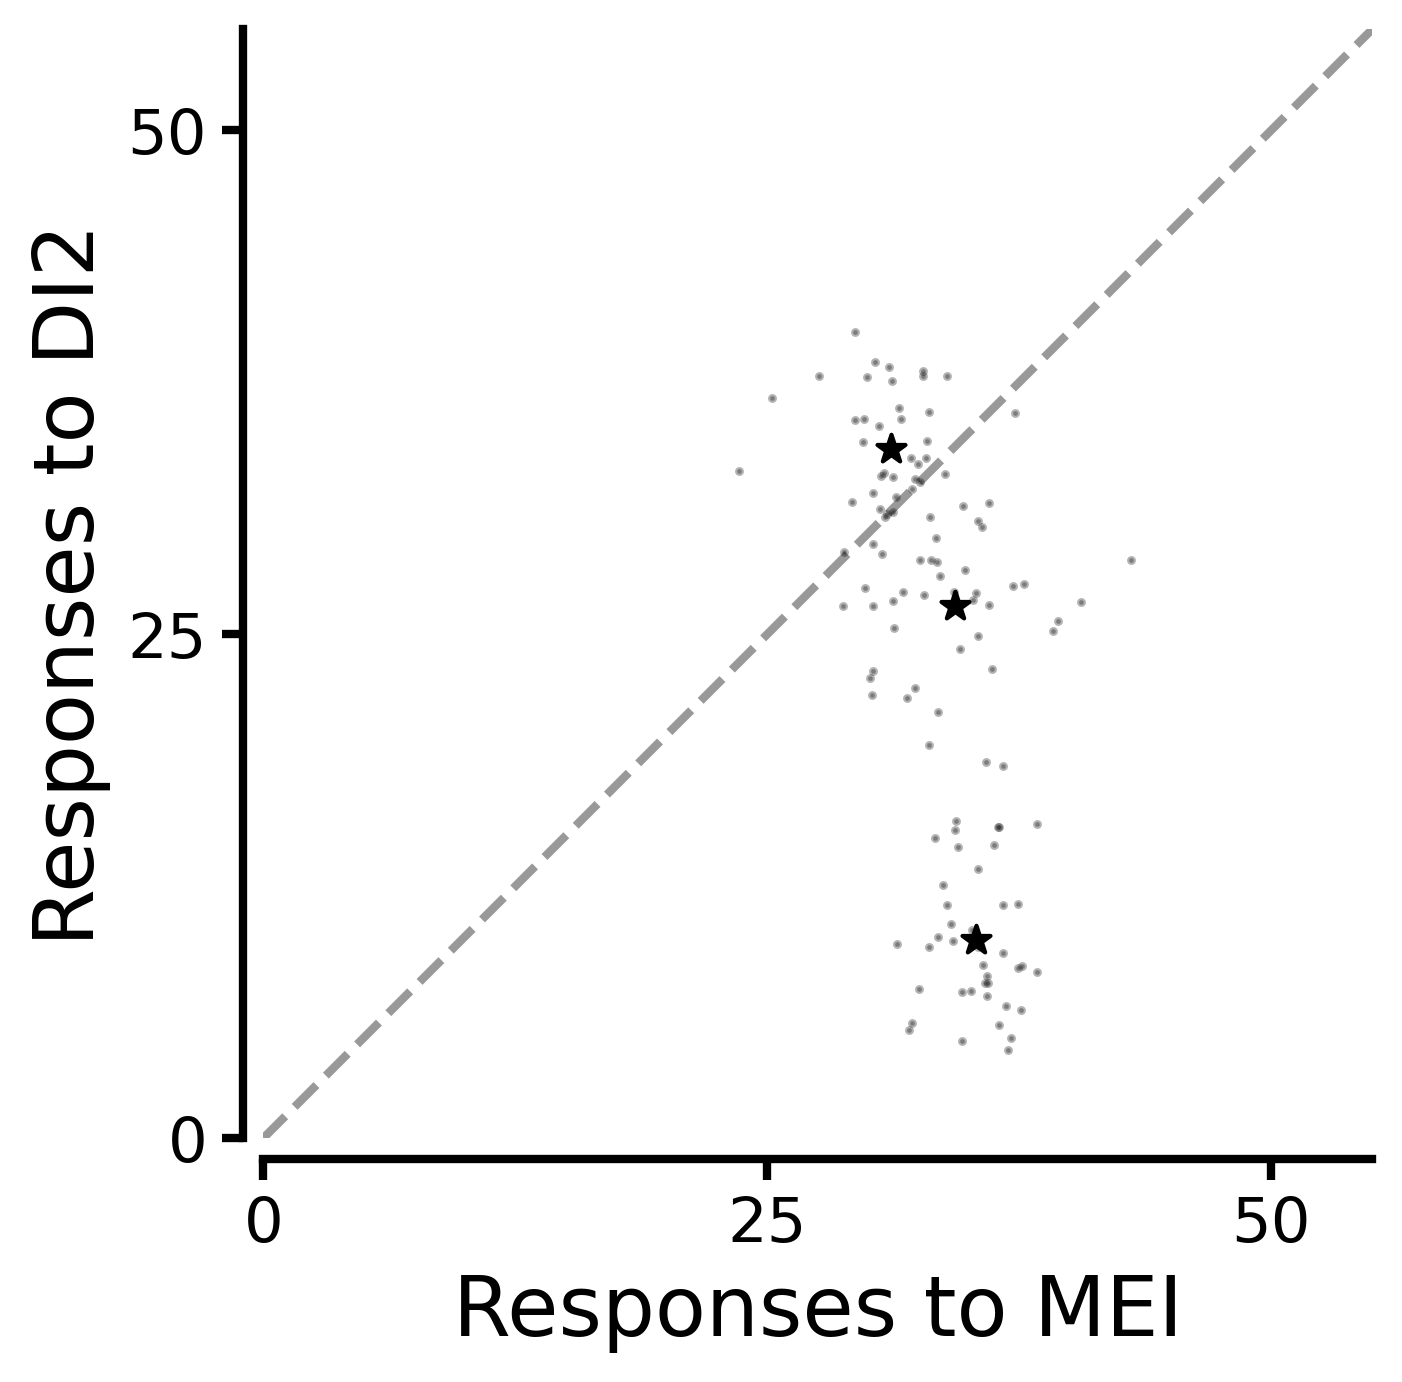

In [25]:
fig, ax = plt.subplots(dpi=300)
ax.plot([0, 55], [0, 55], color="black", linestyle="--", linewidth=2, alpha=0.4)
x = all_mei_rates + rng.normal(0, 1, len(all_mei_rates))
y = all_disrupting_2_rates + rng.normal(0, 1, len(all_completing_rates))
ax.scatter(x, y, marker=".", s=5, color="black", alpha=0.3)
ax.scatter(
    all_mei_means,
    all_disrupting_2_means,
    marker="*",
    s=50,
    color="black",
)
# draw a regression line
m, b = np.polyfit(all_mei_means, all_completing_means, 1)
x_ = np.linspace(0, 50, 1000)
y_ = m * x_ + b
# ax.plot(x_, y_, color='black', linestyle='-', linewidth=1)
# ax.plot(, color='gray', linestyle='--')
ax.set_xlim(0, 55)
ax.set_ylim(0, 55)
ax.set_xticks([0, 25, 50])
ax.set_yticks([0, 25, 50])
ax.tick_params(axis="both", which="major", labelsize=15, width=2, length=5)
# draw diagonal line
# make square
ax.set_box_aspect(1)
ax.set_xlabel("Responses to MEI", fontsize=20)
ax.set_ylabel("Responses to DI2", fontsize=20)
ax.spines[["left", "bottom"]].set_linewidth(2)

sns.despine(ax=ax, offset=5)